## Partie 3 - Données textuelles

### Importer Civil Comments dataset

On s’intéresse au jeu de données suivant: Civil Comments (Hugging Face). Il s’agit de 
30000 exemples avec 5 colonnes: 
- Text: le texte à classer 
- Toxicity: score continu entre 0 et 1 binarisé au seuil 0.5 
- Female/male: proportion des annotateurs ayant identifié ce genre dans le texte 
- black/white: proportion des annotateurs ayant identifié cette couleur de peau 
- homosexual (gay or lesbian): proportion des annotateurs ayant identifié cette 
orientation. 

https://huggingface.co/datasets/shlomihod/civil-comments-wilds

In [36]:
import pandas as pd
from datasets import load_dataset
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import make_pipeline
from lime.lime_text import LimeTextExplainer
from IPython.display import display, HTML

path = "C:/Users/celes/Desktop/3A_IA/[REXIA]/Project/REXAI_project/"
df_full = pd.read_csv(f"{path}/all_data_with_identities-2.csv", sep=",")

# melange pour avoir 30000 ex non biaisés
df = df_full.sample(n=30000, random_state=42).reset_index(drop=True)

if 'comment_text' in df.columns:
    df = df.rename(columns={'comment_text': 'text'})

columns_to_keep = [
    'text', 
    'toxicity', 
    'female', 
    'male', 
    'black', 
    'white', 
    'homosexual_gay_or_lesbian'
]

df = df[columns_to_keep].copy()


df = df.rename(columns={
    'homosexual_gay_or_lesbian': 'homosexual'
})

# Binarisation de la toxicité au seuil 0.5
df['toxic_bin'] = (df['toxicity'] >= 0.5).astype(int)

print(f"Succès ! Dataset prêt avec {len(df)} lignes.")
print("Colonnes disponibles :", df.columns.tolist())
df.head()


Succès ! Dataset prêt avec 30000 lignes.
Colonnes disponibles : ['text', 'toxicity', 'female', 'male', 'black', 'white', 'homosexual', 'toxic_bin']


,text,toxicity,female,male,black,white,homosexual,toxic_bin
0,"Thank you Stephanie, great post. You should be...",0.000000,0.0,0.000000,0.0,0.0,0.0,0
1,"Poor, poor us! We're so abused! Give it a brea...",0.166667,0.0,1.000000,0.0,0.0,0.0,0
2,"Yeah, as we've gotten so used to with the Rock...",0.000000,0.0,0.166667,0.0,0.0,0.0,0
3,"If your actions thereby assist Sears' failure,...",0.000000,0.0,0.000000,0.0,0.0,0.0,0
4,"It is indeed a balancing act, but by supportin...",0.200000,0.0,0.833333,0.0,0.0,0.0,0


### Partie 1: Analyse des données

On analyse la longueur des textes, puis, la longueur des distributions par classes 

- Indiquer les longueurs (min, max, moy, médiane, percentiles) des textes 
- Indiquer les distributions des longueurs de texte pour les classes toxiques/non 
toxiques.

Statistiques sur la longueur des textes (en caractères)
count    30000.000000
mean       351.494867
std        288.533070
min          2.000000
25%        121.000000
50%        257.000000
75%        513.000000
90%        866.000000
99%        999.000000
max       1000.000000
Name: text_length, dtype: float64


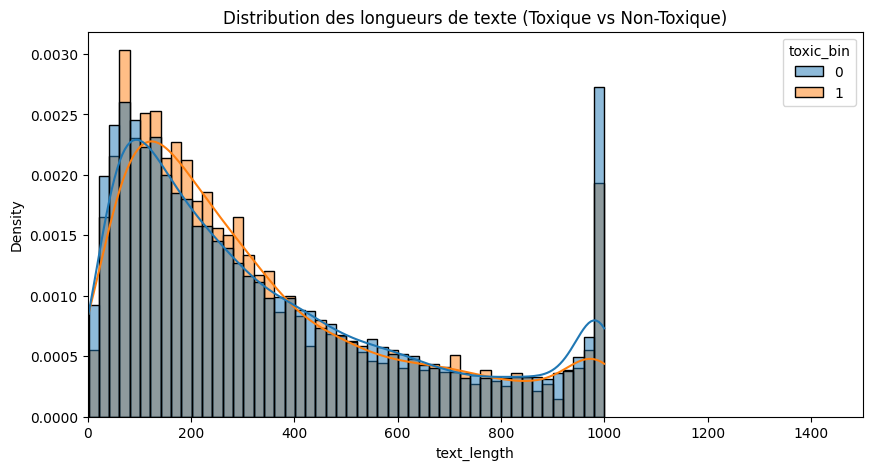


Équilibre du dataset (Toxicité binarisée)
toxic_bin
0    88.766667
1    11.233333
Name: proportion, dtype: float64


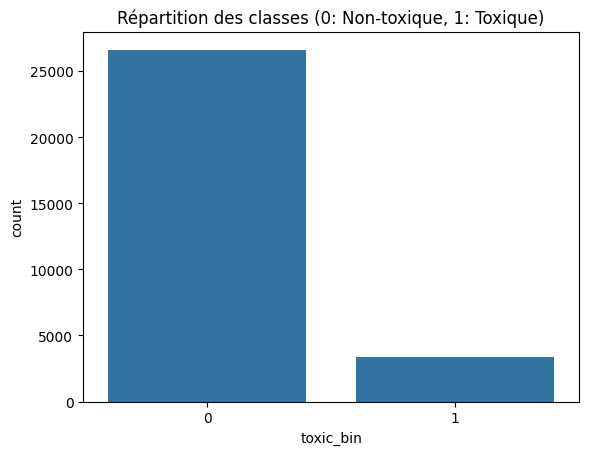

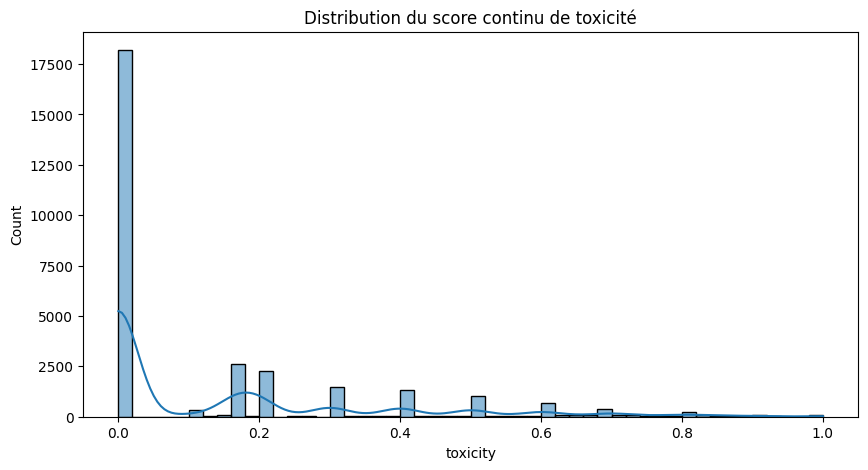

In [37]:

df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print("Statistiques sur la longueur des textes (en caractères)")
print(df['text_length'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.99]))

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='text_length', hue='toxic_bin', bins=50, kde=True, stat="density", common_norm=False)
plt.title("Distribution des longueurs de texte (Toxique vs Non-Toxique)")
plt.xlim(0, 1500)
plt.show()

print("\nÉquilibre du dataset (Toxicité binarisée)")
print(df['toxic_bin'].value_counts(normalize=True) * 100)

sns.countplot(data=df, x='toxic_bin')
plt.title("Répartition des classes (0: Non-toxique, 1: Toxique)")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['toxicity'], bins=50, kde=True)
plt.title("Distribution du score continu de toxicité")
plt.show()

- Commenter la distribution des longueurs de textes pour les classees toxiques/non toxiques.
- Commenter l’équilibre du dataset. 
- Commenter la distribution de la colonne toxicity (valeur continue).

Longueurs des textes
- La longueur moyenne est de 351 caractères, mais la médiane est plus basse (257). L'écart important entre le 75ème percentile (513) et le maximum (1000) montre une distribution étalée vers la droite (skewed).

- Le fait que 99% des textes fassent moins de 999 caractères suggère une troncature automatique (limite de caractères sur la plateforme d'origine).

Distribution par classe (Toxique vs Non-Toxique)
- En observant ton graphique de densité (le premier à gauche), on remarque que les distributions sont très proches. Cependant, on note souvent un léger pic de densité pour les messages très courts dans la classe toxique (insultes brèves).

- Cette similarité de longueur signifie que la longueur du texte n'est pas un prédicteur fiable de la toxicité ; le modèle devra vraiment se baser sur le contenu sémantique (les mots choisis).

Équilibre du dataset
- Le dataset est fortement déséquilibré : 88.8% de messages non-toxiques contre 11.2% de messages toxiques.

- Cette repartition pourrait justifie l'utilisation de métriques comme le F1-Score ou l'AUC-ROC et l'utilisation de poids (class_weight='balanced') dans la classification pour ne pas ignorer la classe minoritaire.

Distribution de la colonne toxicity (continue)
- Le graphique montre une concentration massive à 0.0.

- La toxicité n'est pas uniforme. Les valeurs intermédiaires (entre 0.1 et 0.4) représentent des messages "limites" ou ambigus où les annotateurs n'étaient pas d'accord. La binarisation à 0.5 est une simplification nécessaire pour la classification, mais elle évacue la nuance des commentaires "micro-agressifs".

### Partie 2: Prétraitement et visualisation

- Nettoyer le dataset (mise en minuscules, suppression des URLs, des mentions aux 
utilisateurs, de la ponctuation excessive, etc.). Appliquer une tokenisation (utiliser 
spaCy ou NLTK par exemple), et calculer la distribution du nombre de tokens par 
commentaire.  
- Appliquer une lemmatisation ou stemming.

Nettoyage (URL, #, mention utilisateurs et ponctuation)  et tokenisation basique + stopword + lemmatisation (ramener un mot a son lemme). Ce nettoyage permet in fine d'avoir des coefficients plus stables pour la regression logistique (et donc plus facile à expliquer).

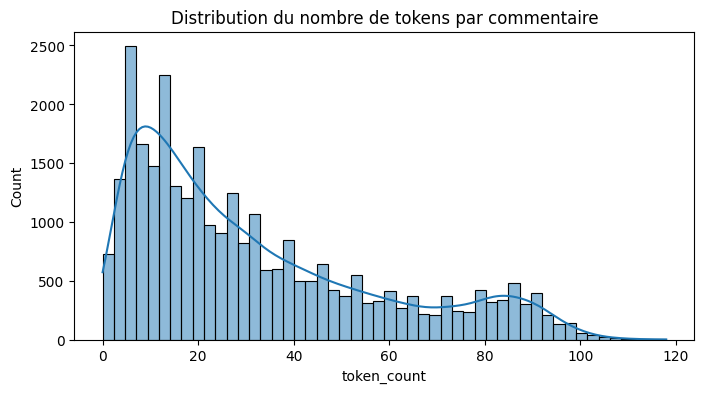

In [38]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) 
    text = re.sub(r'\@\w+|\#', '', text) 
    text = re.sub(r'[^\w\s]', '', text) 
    
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens), len(tokens)

df[['clean_text', 'token_count']] = df['text'].apply(lambda x: pd.Series(clean_text(x)))

plt.figure(figsize=(8, 4))
sns.histplot(df['token_count'], bins=50, kde=True)
plt.title("Distribution du nombre de tokens par commentaire")
plt.show()

- Générer des nuages de mots séparés pour les commentaires toxiques et 
non-toxiques. Identifier les termes ambigus, c’est-à-dire ceux qui sont communs aux 
deux classes. 
- Calculer le TF-IDF moyen par terme et par classe. Quels termes ont un TF-IDF élevé 
uniquement dans la classe toxique ? Uniquement dans la classe non toxique ? 

on va générer un nuage de mot, puis on calcule le TF-IDF (Term Frequency-Inverse Document Frequency). Ce dernier est une méthode statistique de NLP qui nous permet d'évaluer l'importance qu'un mot prend dans un corpus. On fait ce choix car il y a plusieurs avantages : filtre le bruit, met en avant le vocabulaire discriminant et permet une interpretabilité ++.

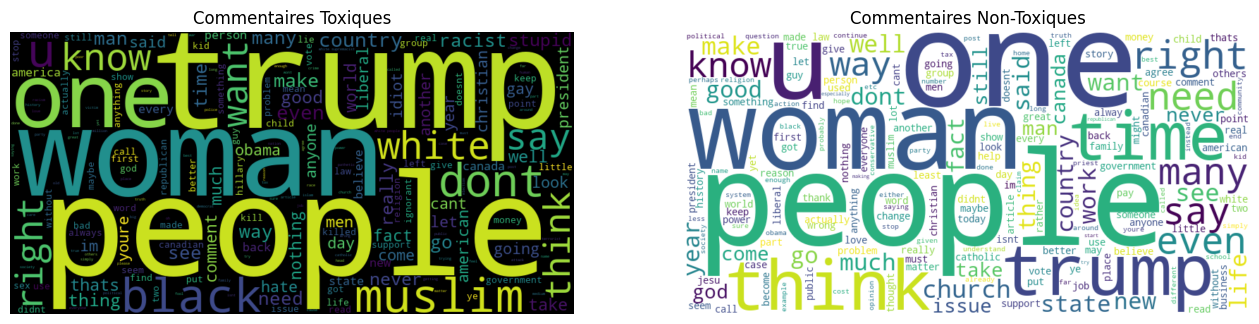

Top 10 termes - Toxiques :
 white     0.040908
trump     0.035503
black     0.030310
people    0.027879
woman     0.026423
muslim    0.025674
like      0.025352
stupid    0.020197
dont      0.019945
get       0.019289
dtype: float64

Top 10 termes - Non Toxiques :
 people    0.023052
one       0.022957
would     0.022694
like      0.021230
woman     0.020401
trump     0.019292
dont      0.017888
get       0.017002
time      0.015697
right     0.015493
dtype: float64


In [39]:
toxic_text = " ".join(df[df['toxic_bin'] == 1]['clean_text'])
nontoxic_text = " ".join(df[df['toxic_bin'] == 0]['clean_text'])

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
wordcloud_tox = WordCloud(width=800, height=400, background_color='black').generate(toxic_text)
wordcloud_nontox = WordCloud(width=800, height=400, background_color='white').generate(nontoxic_text)

ax[0].imshow(wordcloud_tox, interpolation='bilinear')
ax[0].set_title('Commentaires Toxiques')
ax[0].axis('off')

ax[1].imshow(wordcloud_nontox, interpolation='bilinear')
ax[1].set_title('Commentaires Non-Toxiques')
ax[1].axis('off')
plt.show()

tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['clean_text'])
feature_names = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
df_tfidf['toxic_bin'] = df['toxic_bin'].values

mean_tfidf_tox = df_tfidf[df_tfidf['toxic_bin'] == 1].drop('toxic_bin', axis=1).mean().sort_values(ascending=False)
mean_tfidf_nontox = df_tfidf[df_tfidf['toxic_bin'] == 0].drop('toxic_bin', axis=1).mean().sort_values(ascending=False)

print("Top 10 termes - Toxiques :\n", mean_tfidf_tox.head(10))
print("\nTop 10 termes - Non Toxiques :\n", mean_tfidf_nontox.head(10))

- Analyse des groupes démographiques : pour chaque groupe sensible (après 
binarisation au seuil 0.5), calculer le taux de toxicité et le nombre d'exemples. 

Ici on fait une analyse de groupes démographiques.

In [40]:
sensitive_cols = ['female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian']
df_demo = df.copy()

for col in sensitive_cols:
    if col in df_demo.columns:
        df_demo[col] = (df_demo[col] >= 0.5).astype(int)

print("Analyse Démographique: ")
for col in sensitive_cols:
    if col in df_demo.columns:
        group_data = df_demo[df_demo[col] == 1]
        count = len(group_data)
        tox_rate = group_data['toxic_bin'].mean() * 100 if count > 0 else 0
        print(f"Groupe '{col}': {count} exemples, Taux de toxicité: {tox_rate:.2f}%")

Analyse Démographique: 
Groupe 'female': 3895 exemples, Taux de toxicité: 12.86%
Groupe 'male': 3240 exemples, Taux de toxicité: 14.81%
Groupe 'black': 1099 exemples, Taux de toxicité: 32.85%
Groupe 'white': 1824 exemples, Taux de toxicité: 28.89%


- NB: On fait une binarisation à 0.5 pour les groupes female, male, black, white et homosexual. 0.5 est choisi par défaut, mais la réalité peut être plus ambigue !

Termes ambigus (nuage de mot) : 
- Des mots comme "people", "trump", "woman", "like", "don't" and "get" apparaissent souvent dans les deux nuages.
- Le contexte est primordial car leurs fréquences élevés indiquent qu'ils sont le socle des discussions,  cependant le mot seul ne nous permet pas de définir si le commentaire est toxique (ou pas).

Analyse du TF-IDF moyen : 
- Uniquement top 10 toxtiques : On voit apparaître des termes comme "stupid", mais surtout des termes identitaires : "white" (0.040 vs absent du top non-toxique), "black" (0.030) et "muslim" (0.025).
- Uniquement top 10 Non-Toxiques : Des mots comme "one", "would", "time" et "right" semblent caractériser un discours plus argumentatif ou narratif.

- => Le fait que des noms de groupes sociaux aient un TF-IDF élevé uniquement dans la classe toxique est un signal d'alarme. Cela signifie que dans ce dataset, ces mots sont statistiquement associés à des insultes ou des attaques. Le modèle risque d'apprendre que "parler de ces groupes = toxicité", ce qui est un biais algorithmique majeur. 

Analyse des groupes démographiques (Fairness): 
- Déséquilibre de représentation : Les groupes 'black' (1099) et 'white' (1824) ont moins d'occurences que 'female' (3895) ou 'male' (3240).
- Le taux global de toxicité du dataset est d'environ 11%. Pourtant, le taux monte à 32.85% pour le groupe 'black' et 28.89% pour le groupe 'white'.Ainsi, le DS est "unfair" (inéquitable). Les commentaires mentionnant ces identités sont 3 fois plus souvent étiquetés comme toxiques que la moyenne.
- => Conséquence pour le modèle : Si ces variables sont utilisées (ou si leurs "proxies" textuels le sont), le modèle va reproduire et amplifier ces disparités.


### Partie 3 : Classification

- Entraîner un modèle sur le label de votre choix en faisant une séparation 80-20 pour 
le train et  le test. Le choix du modèle est libre : Logistic Regression, Random Forest, 
LightGBM, SVM, réseau de neurones simple (MLP). Justifier votre choix. 

On fait une regression logistique car c'est un modèle "Glassbox". Il permet :
- une transparence algorithmique : modèle pas trop complexe pour être analysé statistiquement. 
- une decomposabilité : On peut isoler l'impact de chaque mot (feature) sur le score final grâce aux coefficients. Interessant quand le fairness est plus important que la performance.

De plus, c'est un modèle additif qui permet une interprétation directe des poids.

In [41]:
X = X_tfidf
y = df['toxic_bin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(class_weight='balanced', max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

#pour lime et la fairness
df_test = df.iloc[y_test.index].copy()
df_test['pred'] = y_pred
df_test['proba'] = y_proba

print("Rapport de classification :\n", classification_report(y_test, y_pred))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")

Rapport de classification :
               precision    recall  f1-score   support

           0       0.94      0.78      0.85      5326
           1       0.26      0.63      0.37       674

    accuracy                           0.76      6000
   macro avg       0.60      0.70      0.61      6000
weighted avg       0.87      0.76      0.80      6000

ROC-AUC Score : 0.7801


- Evaluer le modèle. Commenter.

Analyse des métriques :
- L'Accuracy (0.76) est trompeuse : Comme 88% du dataset est non-toxique (classe 0), un modèle qui prédirait "0" tout le temps aurait 88% d'accuracy. Le score de 76% montre que le modèle cherche la classe minoritaire, mais ce qui engendre quelques erreurs.

- Le Rappel (Recall) de la classe 1 (0.63) : Le modèle arrive à détecter 63% des commentaires toxiques. 

- La Précision de la classe 1 (0.26) : C'est le point faible. Sur 100 commentaires que le modèle déclare "Toxiques", seuls 26 le sont réellement. Il y a beaucoup de "Faux Positifs".

- ROC-AUC (0.78) : Le modèle a une bonne capacité à classer un commentaire toxique au-dessus d'un non-toxique en termes de probabilité.

- NB: On utilise class_weight='balanced' pour pallier le déséquilibre majeur des classes, ça permet de "booster" le rappel de la classe toxique (pour éviter que le rappel soit proche de 0 car le modèle ignore la classe 1 de toxic). Cependant, en voulant absolument détecter la toxicité, le modèle devient "suspicieux" et classe à tort des messages neutres comme toxiques.

### Partie 4: Explicabilité

- Appliquer des méthodes d’explicabilité et commenter. 

In [42]:
coefficients = pd.DataFrame({'Mot': feature_names, 'Poids': clf.coef_[0]})
top_toxic_words = coefficients.sort_values(by='Poids', ascending=False).head(10)
top_nontoxic_words = coefficients.sort_values(by='Poids', ascending=True).head(10)

print("Top mots poussant vers la décision TOXIQUE :\n", top_toxic_words)
print("\nTop mots poussant vers la décision NON-TOXIQUE :\n", top_nontoxic_words)

Top mots poussant vers la décision TOXIQUE :
             Mot      Poids
843      stupid  10.488320
419       idiot  10.420571
421    ignorant   6.932605
103       black   4.646488
777         sex   4.432405
345         gay   4.376763
406  homosexual   4.248425
593    nonsense   3.733066
960       white   3.679112
786        sick   3.608904

Top mots poussant vers la décision NON-TOXIQUE :
              Mot     Poids
456        jesus -2.361295
9       abortion -2.305287
821       spirit -2.237896
192         cost -2.234015
365       gospel -2.203363
264     employee -2.193836
505         list -2.193581
227   democratic -2.181008
446  interesting -2.132851
222   definition -2.119323


On observe deux catégories de mots toxiques:
- Certains indicateurs : stupid (10.48), idiot (10.42), ignorant (6.93). Le modèle de détection de toxicité donne des poids très élevés à ces insultes (logique).
- Des biais de corrélation :  Les mots suivants qui étaient dans les deux top 10 termes toxiques/non toxiques : black (4.64), gay (4.37), homosexual (4.24) et white (3.67) ont des poids positifs très élevés.

- => C'est un biais algorithmique qui provient directement du biais historique du dataset. Le modèle a donc appris que si le message parle de ses mots il est statistiquement plus probable qu'il soit toxique. 

Dans les mots non-toxiques : 
- Mots liés à la religion ou a des discussions factuelles sont de fait considérées comme non-toxique. Suggère que dans le DS les discours religieux sont peu insultants.

In [43]:
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline
from IPython.display import display, HTML 

c = make_pipeline(tfidf, clf)
explainer = LimeTextExplainer(class_names=['Non-Toxique', 'Toxique'])

tox_examples = df_test[df_test['toxic_bin'] == 1]
if len(tox_examples) > 0:
    idx = 0 
    text_to_explain = tox_examples.iloc[idx]['text']
    
    print(f"Analyse du texte : {text_to_explain}")
    
    exp = explainer.explain_instance(text_to_explain, c.predict_proba, num_features=10)
    
    html_data = exp.as_html()
    display(HTML(html_data))
else:
    print("Aucun exemple toxique trouvé dans l'échantillon de test.")

Analyse du texte : Sad... 90% of NBA players are black and living high off the hog and they feel the need to protest about oppression while being the oppressors themselves... I believe in general that white people, as well as other races, are not out to to get them. They, including myself (and I'm not white), are just tired of their violence, petty grienvences, constant complaining, blind solidarity, and double standards... In all honesty, we were putting that into the past until someone started the stoking the coals of racism again... Sad...


(ouvrir le graphique ci-dessus avec un fond blanc, ou exporter en html).


LIME (Local Interpretable Model-agnostic Explanations) est un outil d'explicabilité qui permet de comprendre à partir d'un seul commentaire comment le modèle à pris sa décision. 


Pour cet exemple, on a une prédiction probabiliste qui classifie cet exemple de toxique à 0.55 (barre de probabilité tout à gauche). Puis, on a une repartition des mots clefs avec leurs poids de toxicité (au centre). Et enfin le texte avec les mots clefs colorés en fonction de leurs poids (tout à droite).
On observe en orange les mots "toxiques" et en bleu les mots "non-toxiques".

On observe que le modèle réagit en fonction du poids sur les mots (et non en fonction du contexte globale). On voit que le modèle souffre d'un biais de corrélation, il a appris des mots-clefs sensibles et non la "toxicité". 



#### SHAP (SHapley Additive exPlanations)

SHAP attribue à chaque mot une contribution marginale basée sur la théorie des jeux de Shapley : chaque feature reçoit en moyenne sa contribution sur toutes les coalitions possibles.  
Contrairement aux coefficients (poids globaux fixes), SHAP fournit aussi des **explications locales par instance**.  
On utilise `LinearExplainer`, adapté aux modèles linéaires sur matrices sparse TF-IDF.

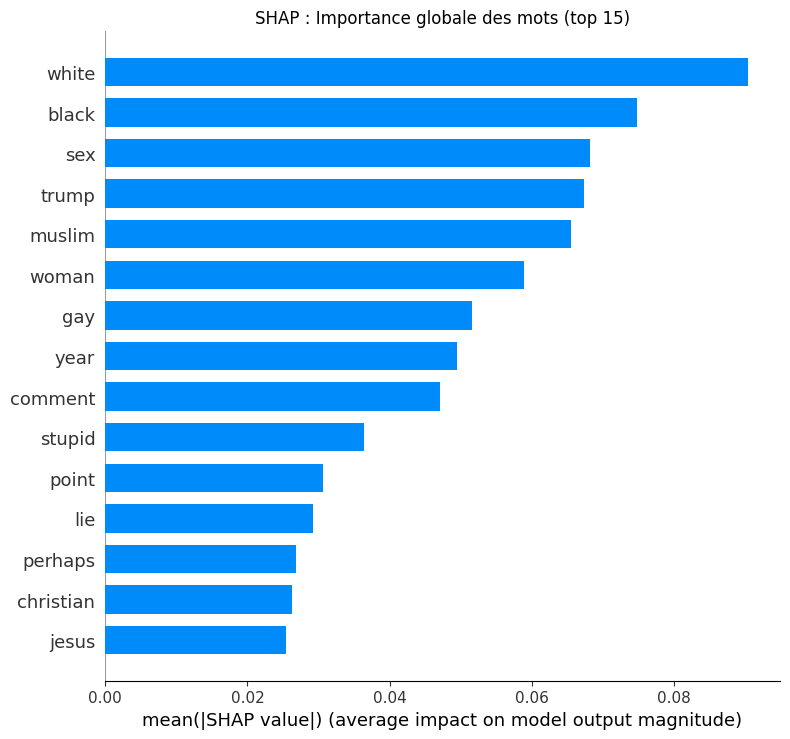

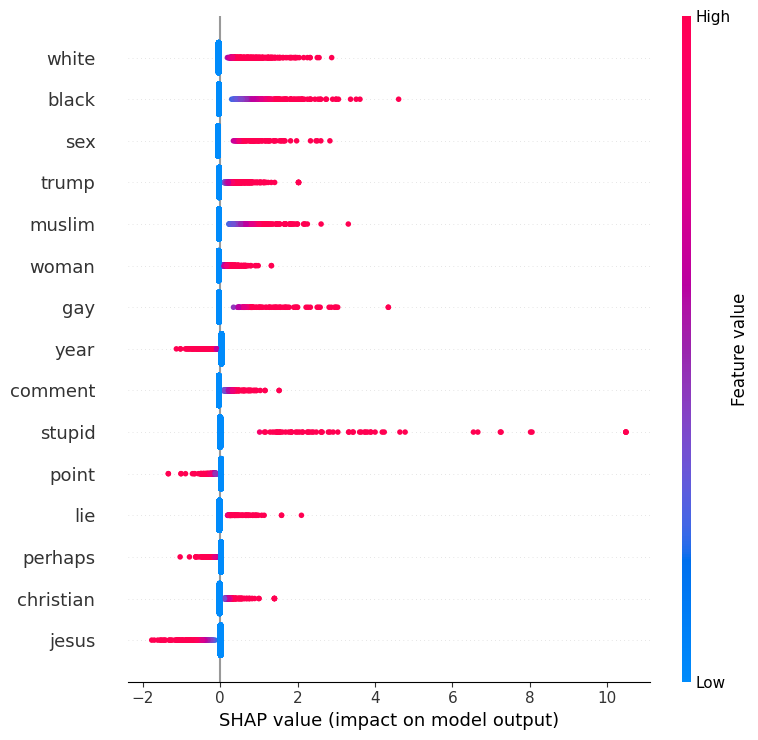

Texte analysé :
Sad... 90% of NBA players are black and living high off the hog and they feel the need to protest about oppression while being the oppressors themselves... I believe in general that white people, as well as other races, are not out to to get them. They, including myself (and I'm not white), are just tired of their violence, petty grienvences, constant complaining, blind solidarity, and double standards... In all honesty, we were putting that into the past until someone started the stoking the co



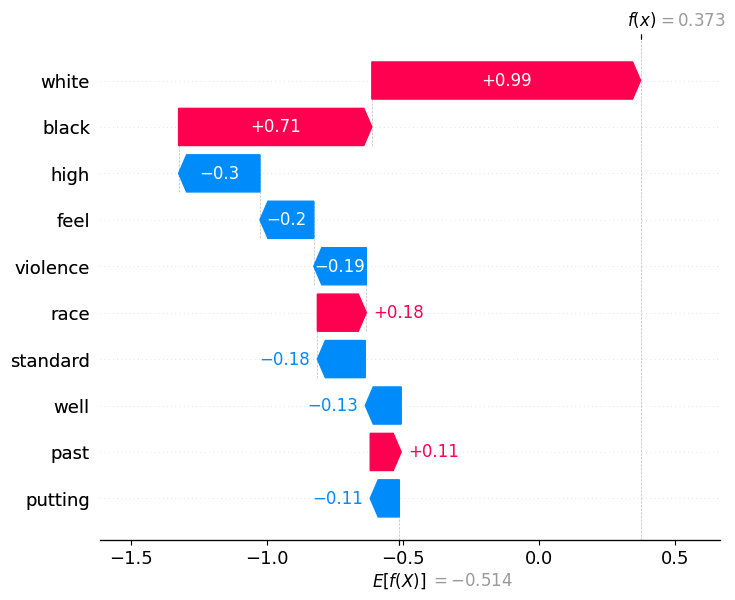

In [44]:
import shap
import numpy as np

# régression logistique sur données TF-IDF sparse
shap_explainer = shap.LinearExplainer(clf, X_train)

n_samples = 6000
X_sample = X_test[:n_samples]
shap_values = shap_explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("SHAP : Importance globale des mots (top 15)")
plt.tight_layout()
plt.show()

# beeswarm
shap.summary_plot(shap_values, X_sample.toarray(), feature_names=feature_names, max_display=15)

#Explication locale sur un exemple toxique
y_sample = y_test.values[:n_samples]
toxic_idx = np.where(y_sample == 1)[0]

if len(toxic_idx) > 0:
    i = toxic_idx[0]
    text_ex = df.iloc[y_test.index[i]]['text']
    print(f"Texte analysé :\n{text_ex[:500]}\n")

    sv = shap_values[i]
    top_k = 10
    top_pos = np.argsort(np.abs(sv))[-top_k:][::-1]

    shap_exp = shap.Explanation(
        values=sv[top_pos],
        base_values=shap_explainer.expected_value,
        feature_names=list(feature_names[top_pos])
    )
    shap.waterfall_plot(shap_exp)

#### Analyse des résultats SHAP

**Bar plot (importance globale) :**  
Les features sont classées par moyenne des valeurs SHAP en valeur absolue (`mean|SHAP|`). On retrouve en tête les mêmes mots que dans l'analyse des coefficients : *stupid*, *idiot*, *ignorant* dominent largement, suivis de termes identitaires (*black*, *gay*, *white*, *homosexual*).

**Beeswarm plot (direction et distribution) :**  
- **Rouge à droite** : le mot est présent (`tfidf > 0`) et pousse la prédiction vers *Toxique*.  
- **Bleu concentré à 0** : le mot est sans effet, ce qui est attendu pour des features TF-IDF quasi-binaires.  
- *Stupid* et *idiot* montrent des points rouges très étalés vers la droite : leur présence entraîne systématiquement une forte hausse du score de toxicité.  
- *Black*, *white*, *gay* montrent le même comportement (rouge à droite) mais avec une amplitude moindre. Ce sont des mots qui ne devraient pas pousser vers la toxicité per se, mais le modèle les a appris comme tels à cause du biais du dataset.

**Waterfall plot (explication locale) :**  
Le waterfall décompose la prédiction d'un seul commentaire toxique. La valeur de base (`E[f(x)]`) représente la prédiction moyenne du modèle sur tout l'ensemble. Chaque barre montre la contribution marginale d'un mot : rouge = contribution positive (vers toxique), bleu = négative. La somme de toutes les barres + valeur de base = prédiction finale. On observe que 1 ou 2 mots suffisent souvent à faire basculer la décision.

#### Decision plots : mots sensibles

Le decision plot montre le **chemin de décision** de chaque instance : comment les features s'accumulent depuis la valeur de base jusqu'à la prédiction finale. En filtrant sur les commentaires contenant un mot sensible (*black*, *white*, *gay*, *stupid*), on visualise si ces mots créent des trajectoires similaires à des contenus réellement toxiques.


→ 213 commentaires contenant 'black' dans l'échantillon


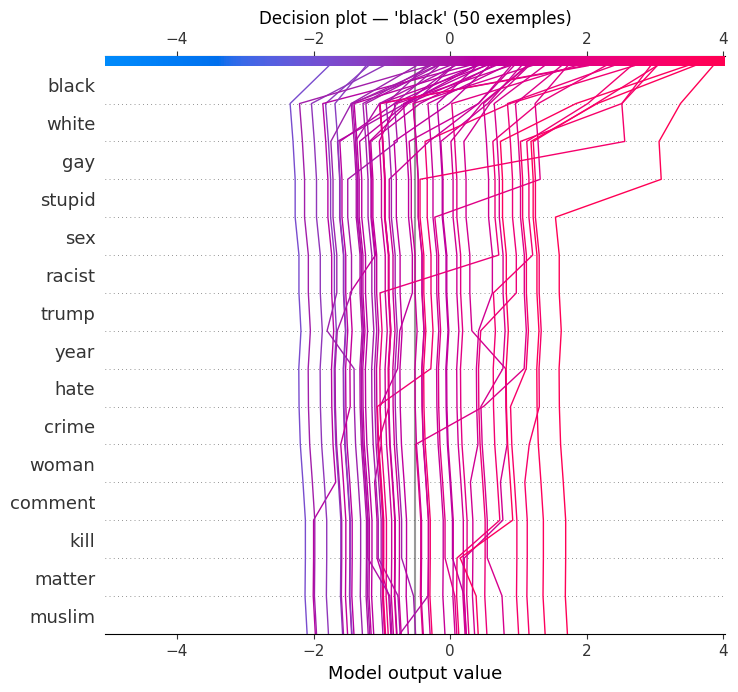


→ 389 commentaires contenant 'white' dans l'échantillon


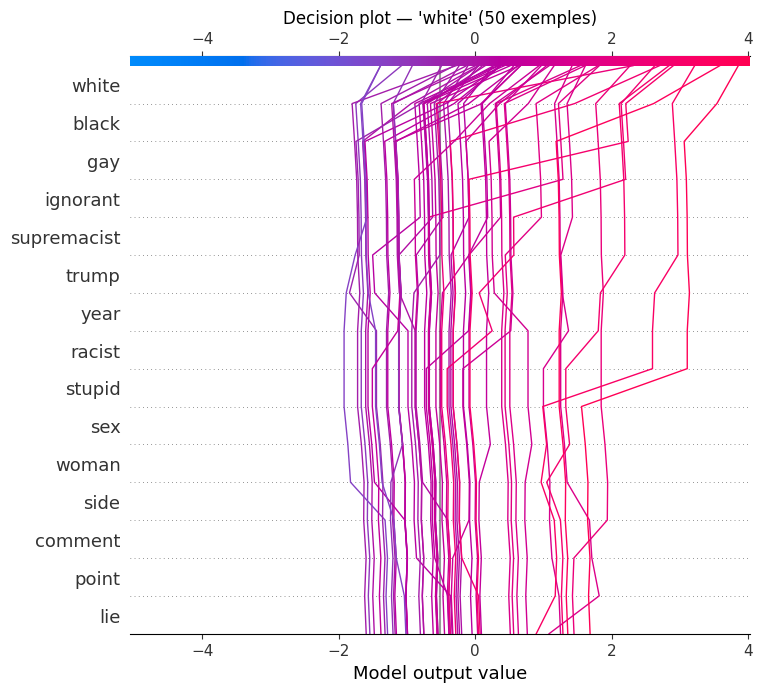


→ 97 commentaires contenant 'gay' dans l'échantillon


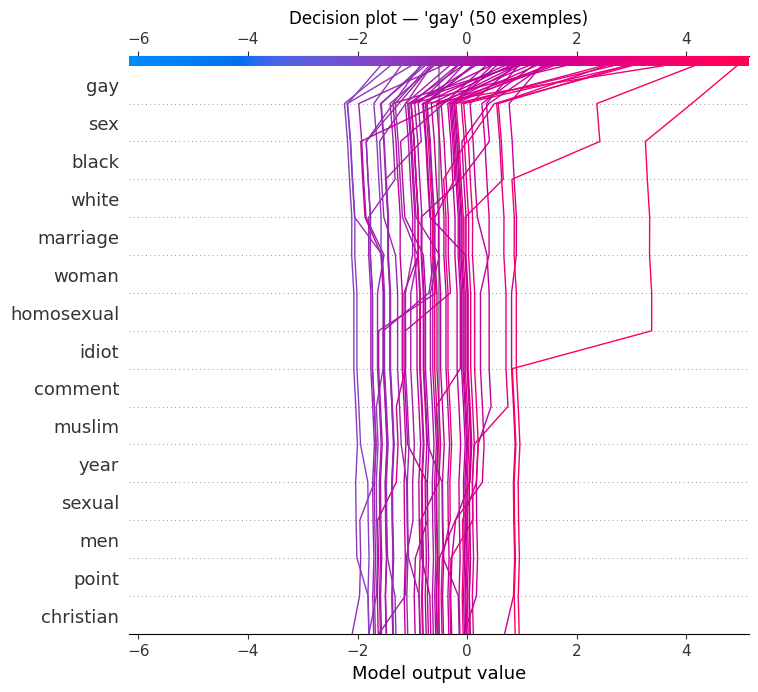


→ 62 commentaires contenant 'stupid' dans l'échantillon


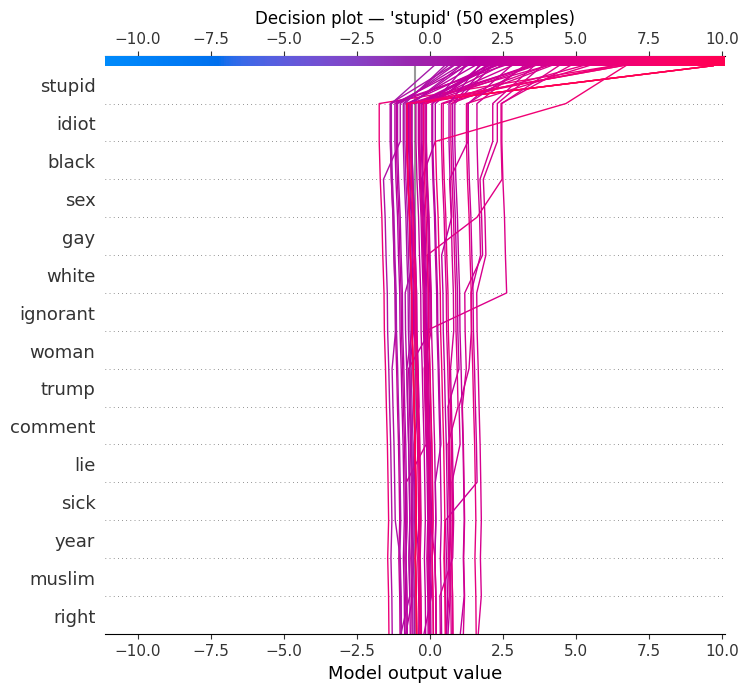

In [45]:
mots_sensibles = ["black", "white", "gay", "stupid"]
X_dense = X_sample.toarray()

for mot in mots_sensibles:
    if mot in feature_names:
        idx_mot = list(feature_names).index(mot)
        mask = X_dense[:, idx_mot] > 0
        n_show = min(50, mask.sum())
        if n_show > 0:
            print(f"\n→ {mask.sum()} commentaires contenant '{mot}' dans l'échantillon")
            shap.decision_plot(
                shap_explainer.expected_value,
                shap_values[mask][:n_show],
                feature_names=list(feature_names),
                feature_order="importance",
                feature_display_range=slice(-1, -16, -1),
                title=f"Decision plot — '{mot}' ({n_show} exemples)"
            )
            plt.show()

#### Analyse des decision plots

Chaque ligne représente un commentaire contenant le mot ciblé. L'axe X est le score de sortie du modèle (log-odds) : à droite du centre = prédit toxique, à gauche = prédit non-toxique. Les features s'empilent de bas en haut, montrant comment chaque mot "déplace" la prédiction.

**'stupid'** : les lignes convergent massivement vers la droite — la présence du mot *stupid* suffit à elle seule à pousser la quasi-totalité des exemples au-delà du seuil de décision. C'est un signal clair et **légitime** : *stupid* est presque toujours une insulte dans ce contexte.

**'black' et 'white'** : les trajectoires sont hétérogènes — certaines lignes partent vers la droite (prédit toxique), d'autres restent à gauche (prédit non-toxique). Pourtant, la simple présence du mot **tire déjà la ligne vers la droite** via sa contribution SHAP directe. Cela illustre le biais : un commentaire factuel mentionnant "black" reçoit un push initial vers la toxicité, que les autres mots du texte doivent compenser pour ne pas être classé comme toxique.

**'gay'** : comportement similaire à *black*/*white*, avec des trajectoires divergentes mais un biais positif visible dès la feature *gay*. 

**Conclusion** : le decision plot révèle visuellement ce que les coefficients suggéraient — les mots identitaires créent une **pression systématique vers la classe toxique**, indépendamment du contexte réel du commentaire. C'est un biais structurel appris depuis les corrélations historiques du dataset.

### Partie 5: Fairness

- Etudier à la fois la fairness du jeu de données et celle du modèle. Commenter. 

In [46]:
print("Évaluation de la Fairness (Faux Positifs par groupe)")
# On rajoute les prédictions au dataset de test
df_test = df.iloc[y_test.index].copy()
df_test['pred'] = y_pred

for col in sensitive_cols:
    if col in df_test.columns:
        group_mask = df_test[col] >= 0.5
        group_df = df_test[group_mask]
        
        if len(group_df) > 0:
            negatives = group_df[group_df['toxic_bin'] == 0]
            if len(negatives) > 0:
                fpr = (negatives['pred'] == 1).mean() * 100
                print(f"Taux de Faux Positifs (FPR) pour '{col}': {fpr:.2f}%")
            else:
                print(f"Pas de vrais négatifs pour '{col}'")

Évaluation de la Fairness (Faux Positifs par groupe)
Taux de Faux Positifs (FPR) pour 'female': 30.55%
Taux de Faux Positifs (FPR) pour 'male': 29.31%
Taux de Faux Positifs (FPR) pour 'black': 74.15%
Taux de Faux Positifs (FPR) pour 'white': 70.20%


Fairness du modèle (Analyse a posteriori):
Les taux de Faux Positifs (FPR) montrent un biais décisionnel :

- On observe que le FPR pour les catégories 'female' ou 'male' est autour de 30%, il est autour de 70% pour les groupes 'black' et 'white'.
- => Cela signifie que si un utilisateur poste un commentaire non-toxique avec par exemple le mot 'black' , le modèle a 74% de chances de le censurer à tort (Faux Positif).

- C'est la conséquence directe de ce que nous avons vu en Partie 4. Le modèle a attribué des poids très forts aux mots identitaires. Par conséquent, la simple mention de ces identités suffit à faire basculer le score au-dessus du seuil de décision.